# 2-Stage Training: Encoder Freeze First → READ Dataset

**Progressive Unfreezing** strategy for fine-tuning TrOCR on the READ Dataset:

| Stage | Encoder | Decoder | LR | Goal |
|---|---|---|---|---|
| **Stage 1** | ❄️ Frozen | 🔥 Trainable | 1e-4 | Decoder learns German grammar & vocabulary |
| **Stage 2** | 🔥 Trainable | 🔥 Trainable | 5e-6 | Full model adapts to READ handwriting style |

Starting point: `microsoft/trocr-base-handwritten` (neutral — no Bentham bias)  
Stage 1 checkpoint: `../checkpoints/stage1_read/`  
Stage 2 checkpoint: `../checkpoints/best_read_2stage/`

## Step 1 – Understand the Dataset

In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt

ROOT     = Path("..")
READ_DIR = ROOT / "data" / "READDataset"

SPLITS = {
    "train": {
        "images": READ_DIR / "Training" / "Images",
        "xmls":   READ_DIR / "Training" / "page" / "page",
    },
    "val": {
        "images": READ_DIR / "Validation" / "Images",
        "xmls":   READ_DIR / "Validation" / "page" / "page",
    },
    "test": {
        "images": READ_DIR / "Test-ICFHR-2016",
        "xmls":   READ_DIR / "Test-ICFHR-2016" / "page",
    },
}

PAGE_NS = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"

print("Paths present:")
for split, paths in SPLITS.items():
    for key, p in paths.items():
        print(f"  {'✓' if p.exists() else '✗'} [{split}/{key}] {p}")

Paths present:
  ✓ [train/images] ../data/READDataset/Training/Images
  ✓ [train/xmls] ../data/READDataset/Training/page/page
  ✓ [val/images] ../data/READDataset/Validation/Images
  ✓ [val/xmls] ../data/READDataset/Validation/page/page
  ✓ [test/images] ../data/READDataset/Test-ICFHR-2016
  ✓ [test/xmls] ../data/READDataset/Test-ICFHR-2016/page


## Step 2 – Extract Line Crops & Build DataFrame

In [3]:
import pandas as pd

KEEP_REGION_TYPES = {"paragraph", "heading"}

def parse_page_xml(xml_path: Path, image_path: Path) -> list:
    ns = {"p": PAGE_NS}
    records = []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path), "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records


def build_dataframe(split_name: str) -> pd.DataFrame:
    paths, records = SPLITS[split_name], []
    for xml_file in sorted(paths["xmls"].glob("*.xml")):
        img_file = paths["images"] / (xml_file.stem + ".JPG")
        if img_file.exists():
            records.extend(parse_page_xml(xml_file, img_file))
    return pd.DataFrame(records)


df_train = build_dataframe("train")
df_val   = build_dataframe("val")
df_test  = build_dataframe("test")

print(f"Train : {len(df_train):>5} lines")
print(f"Val   : {len(df_val):>5} lines")
print(f"Test  : {len(df_test):>5} lines")

Train :  7140 lines
Val   :   894 lines
Test  :  1138 lines


## Step 3 – Preprocess Images

In [4]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"Random seed set to {SEED}")

Random seed set to 42


Crop size : (1212, 105)
Text      : 'mansdorf. Zū NeūPerg. Freÿ¬'


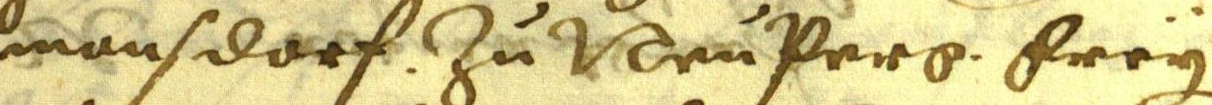

In [5]:
_page_cache: dict = {}

def load_line_image(image_path: str, bbox: tuple) -> Image.Image:
    """Crop one text line from a full-page JPG and return an RGB PIL image."""
    if image_path not in _page_cache:
        _page_cache[image_path] = Image.open(image_path).convert("RGB")
    return _page_cache[image_path].crop(bbox)


row  = df_train.iloc[10]
crop = load_line_image(row["image_path"], row["bbox"])
print(f"Crop size : {crop.size}")
print(f"Text      : '{row['transcription']}'")
crop

## Step 4 – Build Dataset Object

In [6]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
print("Processor loaded from: microsoft/trocr-base-handwritten")

/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Processor loaded from: microsoft/trocr-base-handwritten


In [7]:
from torch.utils.data import Dataset, DataLoader

class READDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df, self.processor = df, processor
        self.max_target_length  = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        img          = load_line_image(row["image_path"], row["bbox"])
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=self.max_target_length, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


train_loader = DataLoader(READDataset(df_train, processor), batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(READDataset(df_val,   processor), batch_size=16, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f"Batch pixel_values : {batch['pixel_values'].shape}")
print(f"Batch labels       : {batch['labels'].shape}")
print("DataLoader OK.")

Batch pixel_values : torch.Size([16, 3, 384, 384])
Batch labels       : torch.Size([16, 128])
DataLoader OK.


## Step 5 – Load Model

Load `trocr-base-handwritten` — neutral starting point, no domain bias.

In [8]:
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.config.use_cache              = False
# Gradient checkpointing is NOT enabled here — it is incompatible with a frozen encoder.
# When encoder params have requires_grad=False, torch.utils.checkpoint cannot propagate
# gradients and emits "None of the inputs have requires_grad=True" → training diverges.
# It is enabled only in Stage 2 (cell-stage2-setup) after the encoder is unfrozen.

model.to(device)
print("Model loaded from: microsoft/trocr-base-handwritten")

Device: cuda


/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded from: microsoft/trocr-base-handwritten


## Step 6 – Stage 1: Encoder Frozen, Decoder Only

The encoder (ViT) is frozen — its visual features stay intact.  
Only the decoder (RoBERTa) trains, learning German vocabulary and grammar from READ.  
Higher LR (1e-4) is safe here since only ~50% of parameters update.  
Best Stage 1 checkpoint saved to `../checkpoints/stage1_read/`.

In [8]:
import evaluate
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm.notebook import tqdm

# Freeze all encoder parameters
for param in model.encoder.parameters():
    param.requires_grad = False

trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
total      = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print("Encoder: ❄️ Frozen   |   Decoder: 🔥 Trainable")

Trainable parameters : 247,268,352 / 333,921,792  (74.0%)
Encoder: ❄️ Frozen   |   Decoder: 🔥 Trainable


In [9]:
EPOCHS_S1     = 20
LR_S1         = 1e-4   # higher LR safe with encoder frozen
WARMUP_RATIO  = 0.1

total_steps_s1  = EPOCHS_S1 * len(train_loader)
warmup_steps_s1 = int(total_steps_s1 * WARMUP_RATIO)

# Only pass trainable (decoder) parameters to optimizer
optimizer_s1 = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_S1,
)
scheduler_s1 = get_scheduler(
    name="linear", optimizer=optimizer_s1,
    num_warmup_steps=warmup_steps_s1, num_training_steps=total_steps_s1,
)

print(f"Stage 1 — Total steps : {total_steps_s1}  |  Warmup : {warmup_steps_s1}  |  LR : {LR_S1}")

Stage 1 — Total steps : 8940  |  Warmup : 894  |  LR : 0.0001


In [10]:
cer_metric     = evaluate.load("cer")
PATIENCE       = 3
S1_CKPT_DIR    = Path("../checkpoints/stage1_read")
S1_CKPT_DIR.mkdir(parents=True, exist_ok=True)

best_cer_s1      = float("inf")
patience_counter = 0
history_s1       = []
scaler           = torch.amp.GradScaler("cuda")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

def compute_cer(model, dataloader, processor, device):
    model.eval()
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"].clone()
            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs  = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    return cer_metric.compute(predictions=all_preds, references=all_refs)


for epoch in range(1, EPOCHS_S1 + 1):

    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"S1 Epoch {epoch:02d}/{EPOCHS_S1} [train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        optimizer_s1.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)
        scaler.scale(outputs.loss).backward()
        scaler.step(optimizer_s1)
        scaler.update()
        scheduler_s1.step()
        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)
    val_cer  = compute_cer(model, val_loader, processor, device)

    history_s1.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"[S1] Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f}", end="")

    if val_cer < best_cer_s1:
        best_cer_s1      = val_cer
        patience_counter = 0
        model.save_pretrained(S1_CKPT_DIR)
        processor.save_pretrained(S1_CKPT_DIR)
        print(f"  ✓ Stage 1 best saved")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping — Stage 1 best Val CER: {best_cer_s1:.4f}")
            break

S1 Epoch 01/20 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

[S1] Epoch 01 | Loss: 3.5057 | Val CER: 0.4467  ✓ Stage 1 best saved


S1 Epoch 02/20 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

[S1] Epoch 02 | Loss: 1.9531 | Val CER: 0.5281  ✗ No improvement (1/3)


S1 Epoch 03/20 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

...

[S1] Epoch 13 | Loss: 0.0350 | Val CER: 0.2252  ✗ No improvement (1/3)


S1 Epoch 14/20 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

[S1] Epoch 14 | Loss: 0.0437 | Val CER: 0.2209  ✗ No improvement (2/3)


S1 Epoch 15/20 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

[S1] Epoch 15 | Loss: 0.0400 | Val CER: 0.2344  ✗ No improvement (3/3)

Early stopping — Stage 1 best Val CER: 0.2117


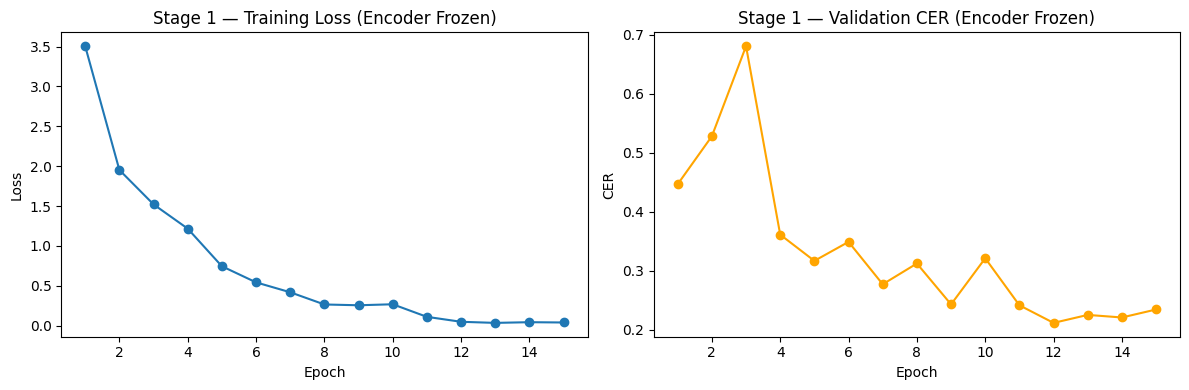

Stage 1 best Val CER: 0.2117 (Epoch 12)


In [11]:
history_s1_df = pd.DataFrame(history_s1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_s1_df["epoch"], history_s1_df["train_loss"], marker="o")
ax1.set_title("Stage 1 — Training Loss (Encoder Frozen)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax2.plot(history_s1_df["epoch"], history_s1_df["val_cer"], marker="o", color="orange")
ax2.set_title("Stage 1 — Validation CER (Encoder Frozen)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("CER")
plt.tight_layout()
plt.show()
print(f"Stage 1 best Val CER: {history_s1_df['val_cer'].min():.4f} (Epoch {history_s1_df['val_cer'].idxmin() + 1})")

## Step 7 – Stage 2: Full Model Fine-Tuning

Load the best Stage 1 checkpoint, unfreeze the encoder, and fine-tune the full model.  
Much lower LR (5e-6) to avoid overwriting what the decoder learned in Stage 1.  
Best Stage 2 checkpoint saved to `../checkpoints/best_read_2stage/`.

In [16]:
import torch
import evaluate
from pathlib import Path
from torch.optim import AdamW
from transformers import VisionEncoderDecoderModel, TrOCRProcessor, get_scheduler
from tqdm.notebook import tqdm

S1_CKPT_DIR = Path("../checkpoints/stage1_read")
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATIENCE    = 3

cer_metric = evaluate.load("cer")

def compute_cer(model, dataloader, processor, device):
    model.eval()
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in dataloader:
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs  = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    return cer_metric.compute(predictions=all_preds, references=all_refs)

# Load best Stage 1 checkpoint
model_s2 = VisionEncoderDecoderModel.from_pretrained(S1_CKPT_DIR)
model_s2.config.use_cache = False
model_s2.gradient_checkpointing_enable()
model_s2.to(device)

# Unfreeze everything
for param in model_s2.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_s2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_s2.parameters())
print(f"Stage 1 checkpoint   : {S1_CKPT_DIR}")
print(f"Trainable parameters : {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")
print("Encoder: 🔥 Trainable   |   Decoder: 🔥 Trainable")

Stage 1 checkpoint   : ../checkpoints/stage1_read
Trainable parameters : 333,921,792 / 333,921,792  (100.0%)
Encoder: 🔥 Trainable   |   Decoder: 🔥 Trainable


In [17]:
EPOCHS_S2    = 30
LR_S2        = 5e-6   # very low — preserve decoder's German knowledge from Stage 1
WARMUP_RATIO = 0.1

total_steps_s2  = EPOCHS_S2 * len(train_loader)
warmup_steps_s2 = int(total_steps_s2 * WARMUP_RATIO)

optimizer_s2 = AdamW(model_s2.parameters(), lr=LR_S2)
scheduler_s2 = get_scheduler(
    name="linear", optimizer=optimizer_s2,
    num_warmup_steps=warmup_steps_s2, num_training_steps=total_steps_s2,
)

print(f"Stage 2 — Total steps : {total_steps_s2}  |  Warmup : {warmup_steps_s2}  |  LR : {LR_S2}")

Stage 2 — Total steps : 13410  |  Warmup : 1341  |  LR : 5e-06


In [18]:
S2_CKPT_DIR      = Path("../checkpoints/best_read_2stage")
S2_CKPT_DIR.mkdir(parents=True, exist_ok=True)

best_cer_s2      = float("inf")
patience_counter = 0
history_s2       = []
scaler_s2        = torch.amp.GradScaler("cuda")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

for epoch in range(1, EPOCHS_S2 + 1):

    model_s2.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"S2 Epoch {epoch:02d}/{EPOCHS_S2} [train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        optimizer_s2.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model_s2(pixel_values=pixel_values, labels=labels)
        scaler_s2.scale(outputs.loss).backward()
        scaler_s2.step(optimizer_s2)
        scaler_s2.update()
        scheduler_s2.step()
        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)
    val_cer  = compute_cer(model_s2, val_loader, processor, device)

    history_s2.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"[S2] Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f}", end="")

    if val_cer < best_cer_s2:
        best_cer_s2      = val_cer
        patience_counter = 0
        model_s2.save_pretrained(S2_CKPT_DIR)
        processor.save_pretrained(S2_CKPT_DIR)
        print(f"  ✓ Stage 2 best saved")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping — Stage 2 best Val CER: {best_cer_s2:.4f}")
            break

S2 Epoch 01/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

[S2] Epoch 01 | Loss: 0.0275 | Val CER: 0.1982  ✓ Stage 2 best saved


S2 Epoch 02/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

[S2] Epoch 02 | Loss: 0.0249 | Val CER: 0.1903  ✓ Stage 2 best saved


S2 Epoch 03/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

...

[S2] Epoch 18 | Loss: 0.0030 | Val CER: 0.1581  ✗ No improvement (1/3)


S2 Epoch 19/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

[S2] Epoch 19 | Loss: 0.0028 | Val CER: 0.1590  ✗ No improvement (2/3)


S2 Epoch 20/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

[S2] Epoch 20 | Loss: 0.0023 | Val CER: 0.1630  ✗ No improvement (3/3)

Early stopping — Stage 2 best Val CER: 0.1497


NameError: name 'history_s1_df' is not defined

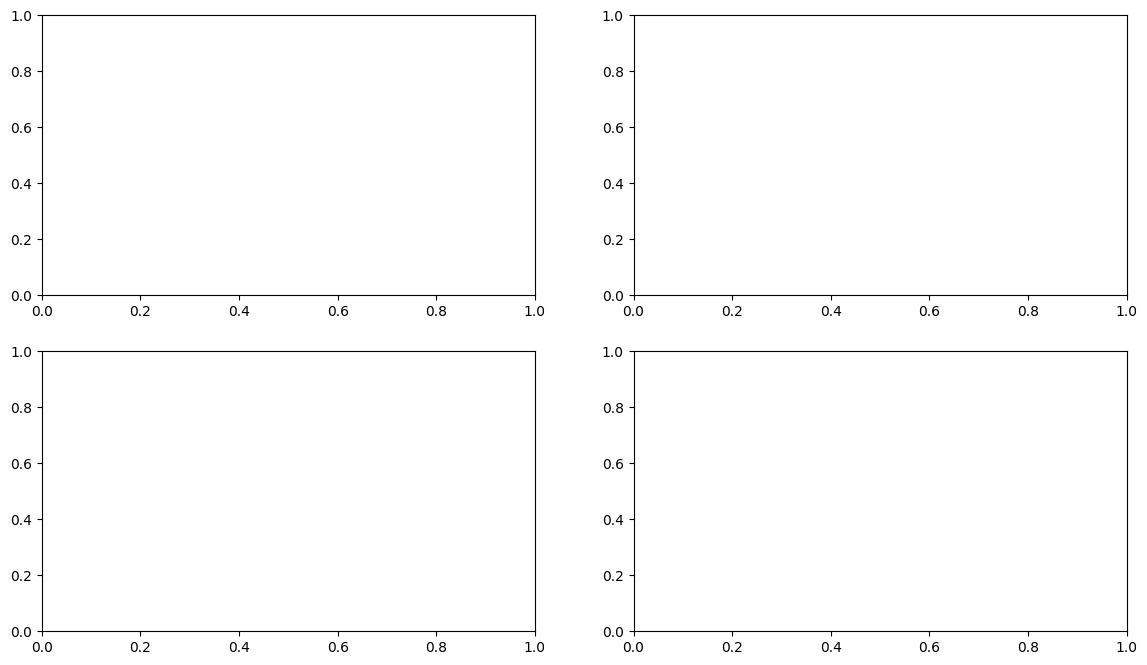

In [19]:
history_s2_df = pd.DataFrame(history_s2)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0][0].plot(history_s1_df["epoch"], history_s1_df["train_loss"], marker="o", color="steelblue")
axes[0][0].set_title("Stage 1 — Training Loss")
axes[0][0].set_xlabel("Epoch"); axes[0][0].set_ylabel("Loss")

axes[0][1].plot(history_s1_df["epoch"], history_s1_df["val_cer"], marker="o", color="orange")
axes[0][1].set_title("Stage 1 — Validation CER")
axes[0][1].set_xlabel("Epoch"); axes[0][1].set_ylabel("CER")

axes[1][0].plot(history_s2_df["epoch"], history_s2_df["train_loss"], marker="o", color="steelblue")
axes[1][0].set_title("Stage 2 — Training Loss")
axes[1][0].set_xlabel("Epoch"); axes[1][0].set_ylabel("Loss")

axes[1][1].plot(history_s2_df["epoch"], history_s2_df["val_cer"], marker="o", color="orange")
axes[1][1].set_title("Stage 2 — Validation CER")
axes[1][1].set_xlabel("Epoch"); axes[1][1].set_ylabel("CER")

plt.suptitle("Progressive Unfreezing: Stage 1 (Encoder Frozen) → Stage 2 (Full Model)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Stage 1 best Val CER : {history_s1_df['val_cer'].min():.4f}")
print(f"Stage 2 best Val CER : {history_s2_df['val_cer'].min():.4f}")

## Step 8 – Evaluation

Load best Stage 2 checkpoint → CER & WER on the test set → qualitative comparison.  
Self-contained: can be run after a kernel restart without retraining.

In [20]:
import torch
import evaluate
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

READ_DIR          = Path("../data/READDataset")
S2_CKPT_DIR       = Path("../checkpoints/best_read_2stage")
PAGE_NS           = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
KEEP_REGION_TYPES = {"paragraph", "heading"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _parse_xml(xml_path, image_path):
    ns, records = {"p": PAGE_NS}, []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path), "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records

test_xml_dir = READ_DIR / "Test-ICFHR-2016" / "page"
test_img_dir = READ_DIR / "Test-ICFHR-2016"
records = []
for xml_file in sorted(test_xml_dir.glob("*.xml")):
    img_file = test_img_dir / (xml_file.stem + ".JPG")
    if img_file.exists():
        records.extend(_parse_xml(xml_file, img_file))
df_test_eval = pd.DataFrame(records)

best_model     = VisionEncoderDecoderModel.from_pretrained(S2_CKPT_DIR).to(device)
best_processor = TrOCRProcessor.from_pretrained(S2_CKPT_DIR)
best_model.eval()

print(f"Device     : {device}")
print(f"Checkpoint : {S2_CKPT_DIR}")
print(f"Test lines : {len(df_test_eval)}")

Device     : cuda
Checkpoint : ../checkpoints/best_read_2stage
Test lines : 1138


In [21]:
class _READDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df, self.processor = df, processor
        self.max_target_length  = max_target_length
        self._cache = {}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if row["image_path"] not in self._cache:
            self._cache[row["image_path"]] = Image.open(row["image_path"]).convert("RGB")
        img          = self._cache[row["image_path"]].crop(row["bbox"])
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=self.max_target_length, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

test_loader = DataLoader(
    _READDataset(df_test_eval, best_processor),
    batch_size=16, shuffle=False, num_workers=0,
)

all_preds, all_refs = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].clone()
        generated_ids = best_model.generate(pixel_values, max_new_tokens=128)
        preds = best_processor.batch_decode(generated_ids, skip_special_tokens=True)
        labels[labels == -100] = best_processor.tokenizer.pad_token_id
        refs  = best_processor.batch_decode(labels, skip_special_tokens=True)
        all_preds.extend(preds)
        all_refs.extend(refs)

cer = cer_metric.compute(predictions=all_preds, references=all_refs)
wer = wer_metric.compute(predictions=all_preds, references=all_refs)

print(f"\nTest CER : {cer:.4f}  ({cer*100:.2f}%)")
print(f"Test WER : {wer:.4f}  ({wer*100:.2f}%)")

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]


Test CER : 0.1597  (15.97%)
Test WER : 0.4299  (42.99%)


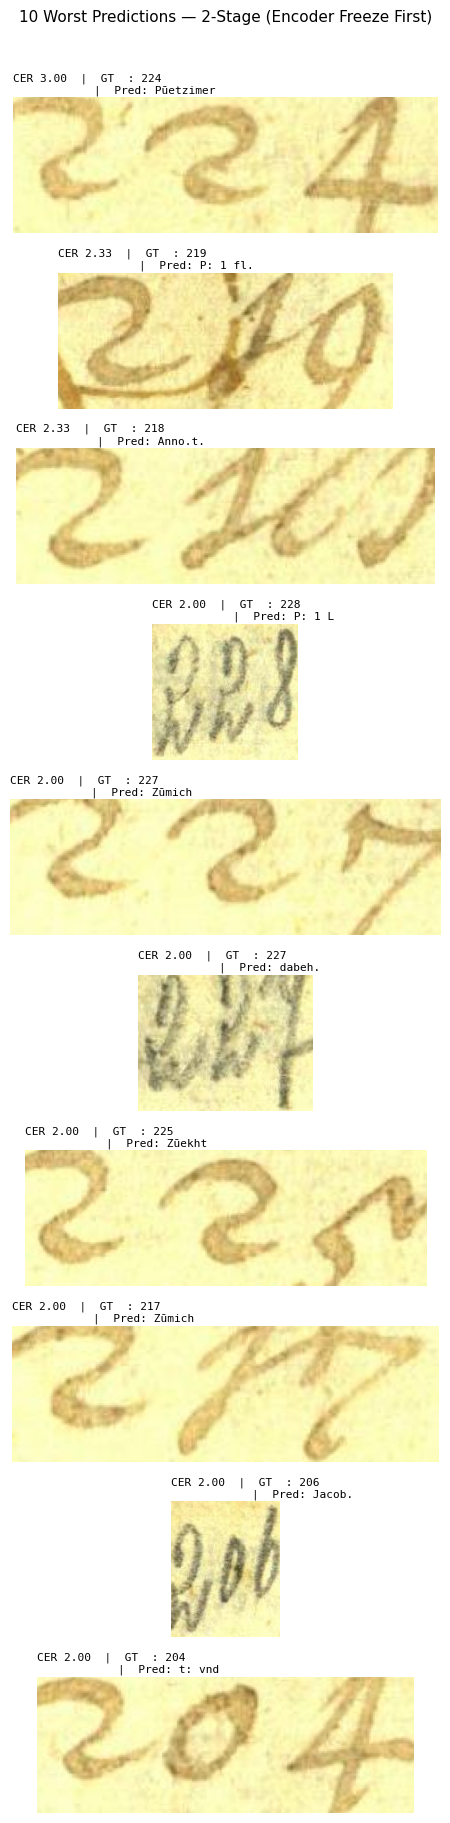

Saved to ../checkpoints/best_read_2stage/worst_predictions.png


In [22]:
import matplotlib.pyplot as plt
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(all_preds, all_refs)) if ref.strip()],
    reverse=True,
)
worst = errors[:10]

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, (c, idx, ref, pred) in zip(axes, worst):
    row = df_test_eval.iloc[idx]
    img = Image.open(row["image_path"]).crop(row["bbox"])
    ax.imshow(img)
    ax.set_title(
        f"CER {c:.2f}  |  GT  : {ref}\n"
        f"            |  Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — 2-Stage (Encoder Freeze First)", fontsize=11, y=1.01)
plt.tight_layout()

output_path = Path("../checkpoints/best_read_2stage/worst_predictions.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {output_path}")